In [12]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from collections import defaultdict

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker

import calendar
import string
import matplotlib.patches as mpatches

In [13]:
class ETCTrackMonthlyDensityCalculator:
    def __init__(self, filepath, bin_size=(4.0, 4.0), syear=2008, eyear=2017):
        self.filepath = filepath
        self.bin_size = bin_size
        self.syear = syear
        self.eyear = eyear

        self.lat_bins = np.arange(-90, 90 + bin_size[0], bin_size[0])
        self.lon_bins = np.arange(-180, 180 + bin_size[1], bin_size[1])
        self.monthly_counts = defaultdict(lambda: np.zeros((len(self.lat_bins)-1, len(self.lon_bins)-1), dtype=int))

    def parse_tracks(self):
        with open(self.filepath, 'r') as f:
            lines = f.readlines()

        storm_id = -1
        for line in lines:
            if line.startswith('start'):
                storm_id += 1
                continue

            parts = line.strip().split()
            if len(parts) < 11:
                continue
            try:
                lon = float(parts[2])
                lat = float(parts[3])
                year = int(parts[7])
                month = int(parts[8])

                if not (self.syear <= year <= self.eyear):
                    continue

                # Normalize lon to [-180, 180]
                if lon > 180:
                    lon -= 360

                lat_idx = np.digitize(lat, self.lat_bins) - 1
                lon_idx = np.digitize(lon, self.lon_bins) - 1

                if 0 <= lat_idx < len(self.lat_bins)-1 and 0 <= lon_idx < len(self.lon_bins)-1:
                    self.monthly_counts[(year, month)][lat_idx, lon_idx] += 1
            except Exception as e:
                print(f"[WARN] Failed to parse line: {line.strip()} => {e}")

    def to_xarray(self):
        months = list(range(1, 13))
        lat_centers = 0.5 * (self.lat_bins[:-1] + self.lat_bins[1:])
        lon_centers = 0.5 * (self.lon_bins[:-1] + self.lon_bins[1:])

        # Sum over years per month
        data = np.zeros((12, len(lat_centers), len(lon_centers)), dtype=int)
        for (year, month), grid in self.monthly_counts.items():
            data[month-1] += grid

        da = xr.DataArray(
            data,
            dims=("month", "lat", "lon"),
            coords={
                "month": months,
                "lat": lat_centers,
                "lon": lon_centers
            },
            name="track_density"
        )
        return da

    def save_to_netcdf(self, output_path):
        da = self.to_xarray()
        da.to_netcdf(output_path)
        print(f"[SAVED] Monthly track density to {output_path}")


In [14]:
class ETCTrackDensityPlotter:
    def __init__(self, data_dir, exp_dict, syear, eyear,
                 obs_label="ERA5", label_map=None, binsize="bin5x5"):
        self.data_dir = data_dir
        self.exp_dict = exp_dict
        self.syear = syear
        self.eyear = eyear
        self.obs_label = obs_label
        self.label_map = label_map or exp_dict
        self.binsize = binsize
        self.varname = "track_density"
        self.metric_data = {}
        self.color_map = {
            "ERA5": "black",
            "NDGUVTQ_SRF1": "red"
        }
        
    def normalize_lon(self, lon):
        lon_vals = lon.values if hasattr(lon, "values") else np.array(lon)
        return np.where(lon_vals > 180, lon_vals - 360, lon_vals)

    def get_and_normalize_longitude(self, ds):
        for lon_name in ['lon', 'longitude', 'LONG', 'x']:
            if lon_name in ds.coords:
                norm_lon = self.normalize_lon(ds[lon_name])
                ds = ds.assign_coords({lon_name: norm_lon})
                ds = ds.sortby(lon_name)
                if lon_name != 'lon':
                    ds = ds.rename({lon_name: 'lon'})
                return ds
        print("[WARN] No recognized longitude coordinate found.")
        return ds

    def compute_pattern_corr_exclude_zeros(self, da1, da2):
        arr1 = da1.values.flatten()
        arr2 = da2.values.flatten()
        mask = np.isfinite(arr1) & np.isfinite(arr2) & (arr1 != 0)
        if np.sum(mask) < 2:
            return np.nan
        return pearsonr(arr1[mask], arr2[mask])[0]

    def compute_rmse(self, da1, da2):
        arr1 = da1.values.flatten()
        arr2 = da2.values.flatten()
        mask = np.isfinite(arr1) & np.isfinite(arr2) & (arr1 != 0)
        if np.sum(mask) < 2:
            return np.nan
        return np.sqrt(np.mean((arr1[mask] - arr2[mask]) ** 2))

    def load_and_compute_climatology(self, metric="track_all"):
        all_labels = [self.obs_label] + list(self.experiments)
        metric_data = {}
        for label in all_labels:
            yearly_data = []
            for year in range(self.syear, self.eyear + 1):
                fname = f"{label}_monthly_{metric.replace('track_', 'Track_')}_{year}.nc"
                fpath = os.path.join(self.data_dir, label, fname)
                if not os.path.exists(fpath):
                    print(f"[WARN] Missing file: {fpath}")
                    continue
                try:
                    ds = xr.open_dataset(fpath)
                    ds = self.get_and_normalize_longitude(ds)
                    if 'month' in ds[self.varname].dims:
                        var_da = ds[self.varname]
                        if "year" not in var_da.dims:
                            var_da = var_da.expand_dims(year=[year])
                        yearly_data.append(var_da)
                except Exception as e:
                    if "Dimension" in str(e) and "already exists" in str(e):
                        print(f"[SKIP] {fname} already has 'year' dimension.")
                    else:
                        print(f"[ERROR] Reading {fpath}: {e}")
                    continue
            if yearly_data:
                da = xr.concat(yearly_data, dim='year').mean(dim='year')
                metric_data[label] = da.sum(dim='month')  # mean over month + year
                print(f"[INFO] Loaded {len(yearly_data)} years for {label} ({metric})")
            else:
                metric_data[label] = None
        return metric_data
    
    def load_and_compute_annual_cycle(self, metric="track_all"):
        all_labels = [self.obs_label] + list(self.experiments)
        monthly_data = {}
        for label in all_labels:
            monthly_list = []
            for year in range(self.syear, self.eyear + 1):
                fname = f"{label}_monthly_{metric.replace('track_', 'Track_')}_{year}.nc"
                fpath = os.path.join(self.data_dir, label, fname)
                if not os.path.exists(fpath):
                    print(f"[WARN] Missing file: {fpath}")
                    continue
                try:
                    ds = xr.open_dataset(fpath)
                    ds = self.get_and_normalize_longitude(ds)
                    if 'month' in ds[self.varname].dims:
                        var_da = ds[self.varname]
                        if "year" not in var_da.dims:
                            var_da = var_da.expand_dims(year=[year])
                        monthly_list.append(var_da)
                except Exception as e:
                    print(f"[ERROR] Reading {fpath}: {e}")
                    continue
            if monthly_list:
                da = xr.concat(monthly_list, dim='year').mean(dim='year')
                monthly_data[label] = da
                print(f"[INFO] Loaded {len(monthly_list)} years for {label} ({metric})")
            else:
                monthly_data[label] = None
        return monthly_data

    def _average_region(self, da, region):
        lat1, lat2, lon1, lon2 = region
        region_da = da.sel(lat=slice(lat1, lat2))
        if lon1 < lon2:
            region_da = region_da.sel(lon=slice(lon1, lon2))
        else:
            region_da = region_da.where((da.lon >= lon1) | (da.lon <= lon2), drop=True)
        return region_da.mean(dim=("lat", "lon"), skipna=True)

    def plot(self, metrics=["Track_all", "Track_P990"], cmap="hot_r",
             clevels=None, cticks=None, vmin=None, vmax=None,
             figsize=(14, 12), save_path=None, fontz=14, hspace=0.2, wspace=0.15):
        self.metric_data = {}
        for metric in metrics:
            self.metric_data[metric] = self.load_and_compute_climatology(metric=metric)

        all_labels = [self.obs_label] + list(self.experiments[:5])
        nrows = len(all_labels)
        ncols = len(metrics)

        fig = plt.figure(figsize=figsize)
        spec = gridspec.GridSpec(nrows=nrows, ncols=ncols, hspace=hspace, wspace=wspace)

        axs = []
        for i, label in enumerate(all_labels):
            for j, metric in enumerate(metrics):
                ax = fig.add_subplot(spec[i, j], projection=ccrs.PlateCarree())
                axs.append((label, metric, ax))

        norm = BoundaryNorm(clevels, plt.get_cmap(cmap).N, extend='both') if clevels else None
        mesh = None

        for idx, (label, metric, ax) in enumerate(axs):
            da = self.metric_data[metric].get(label, None)
            if da is None:
                ax.axis("off")
                continue

            ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
            ax.coastlines()
            gl = ax.gridlines(draw_labels=True, linewidth=0.2, linestyle='--', alpha=0.6)
            gl.top_labels = gl.right_labels = False
            gl.xlabel_style = gl.ylabel_style = {'size': fontz - 2}

            mesh = ax.pcolormesh(da.lon, da.lat, da, transform=ccrs.PlateCarree(),
                                 cmap=cmap, norm=norm, vmin=vmin, vmax=vmax, shading="auto")

            row_title = self.label_map.get(label, label)
            col_label = "All" if metric.lower() == "track_all" else "Pmin < 990 hPa"
            panel_label = f"({chr(97 + idx)})"
            ax.set_title(f"{panel_label} {row_title}", fontsize=fontz, loc='left')
            ax.set_title(f"{col_label}", fontsize=fontz, loc='right')

            if label != self.obs_label:
                ref = self.metric_data[metric].get(self.obs_label)
                if ref is not None and ref.shape == da.shape:
                    corr = self.compute_pattern_corr_exclude_zeros(ref, da)
                    rmse = self.compute_rmse(ref, da)
                    text = f"PCC: {corr:.2f}\nRMSE: {rmse:.2f}"
                    ax.text(
                        0.98, 0.5, text,
                        transform=ax.transAxes, fontsize=fontz - 2,
                        ha='right', va='center',
                        bbox=dict(facecolor='white', alpha=1.0, edgecolor='gray', boxstyle='round,pad=0.2')
                    )

        if mesh:
            cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
            cbar = plt.colorbar(mesh, cax=cax, orientation="vertical")
            if cticks:
                cbar.set_ticks(cticks)
            elif clevels:
                cbar.set_ticks([(clevels[i] + clevels[i+1]) / 2 for i in range(len(clevels)-1)])
            cbar.ax.tick_params(labelsize=fontz - 2)
            cbar.set_label("Track Density (per year)", fontsize=fontz)

        if save_path:
            plt.savefig(save_path, dpi=600, bbox_inches='tight')
            print(f"[SAVED] {save_path}")
        plt.show()
        plt.close()

    def plot_annual_cycle(self, hemisphere_dict, metrics=["Track_all", "Track_P990"],
                          figsize=(14, 8), fontz=12, save_path=None, use_month_abbrev=True):

        monthly_metric_data = {m: self.load_and_compute_annual_cycle(metric=m) for m in metrics}

        # === Assign default colors to any experiments missing from color_map ===
        default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        used_keys = set(self.color_map.keys())
        available_exps = [exp for exp in self.exp_dict if exp not in used_keys]
        available_colors = [c for c in default_colors if c not in ["black", "red"]]
        for exp, color in zip(available_exps, available_colors):
            self.color_map[exp] = color

        # === Setup panel and x-axis labels ===
        panel_labels = list(string.ascii_lowercase)
        month_ticks = list(range(1, 13))
        month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'] if use_month_abbrev else list(map(str, month_ticks))

        fig, axs = plt.subplots(2, 2, figsize=figsize, sharex=True)
        axs = axs.flatten()

        for i, (hemi, region) in enumerate(hemisphere_dict.items()):
            for j, metric in enumerate(metrics):
                ax = axs[i * 2 + j]
                panel_label = f"({panel_labels[i * 2 + j]}) {hemi}"
                title_right = "All" if metric.lower() == "track_all" else "Pmin < 990 hPa"

                ax.set_title(panel_label, fontsize=fontz, loc="left")
                ax.set_title(title_right, fontsize=fontz, loc="right")

                # === Get ERA5 data first ===
                da_ref = monthly_metric_data[metric].get(self.obs_label, None)
                reg_mean_ref = None
                if da_ref is not None and "month" in da_ref.dims:
                    lat1, lat2, lon1, lon2 = region
                    reg_da = da_ref.sel(lat=slice(lat1, lat2))
                    reg_da = reg_da.sel(lon=slice(lon1, lon2)) if lon1 < lon2 else reg_da.where((da_ref.lon >= lon1) | (da_ref.lon <= lon2), drop=True)
                    reg_mean_ref = reg_da.mean(dim=("lat", "lon"), skipna=True)

                    ax.bar(month_ticks, reg_mean_ref, label=self.label_map.get(self.obs_label, self.obs_label),
                           color='grey', alpha=0.6, width=0.7, edgecolor='k', zorder=2)

                # === Loop over models ===
                for exp in self.exp_dict:
                    if exp == self.obs_label:
                        continue
                    da = monthly_metric_data[metric].get(exp, None)
                    if da is None or "month" not in da.dims:
                        continue

                    lat1, lat2, lon1, lon2 = region
                    reg_da = da.sel(lat=slice(lat1, lat2))
                    reg_da = reg_da.sel(lon=slice(lon1, lon2)) if lon1 < lon2 else reg_da.where((da.lon >= lon1) | (da.lon <= lon2), drop=True)
                    reg_mean = reg_da.mean(dim=("lat", "lon"), skipna=True)

                    color = self.color_map.get(exp, None)
                    label = self.label_map.get(exp, exp)

                    # === Plot line ===
                    ax.plot(month_ticks, reg_mean, label=label, linewidth=1.8, color=color, zorder=3)

                    # === Compute correlation with ERA5 ===
                    if reg_mean_ref is not None:
                        mask = np.isfinite(reg_mean.values) & np.isfinite(reg_mean_ref.values)
                        if np.sum(mask) >= 2:
                            corr = np.corrcoef(reg_mean.values[mask], reg_mean_ref.values[mask])[0, 1]
                            corr_str = f"{label}: r={corr:.2f}"
                            #ax.text(0.02, 0.95 - 0.06 * list(self.exp_dict).index(exp), corr_str,
                            #        transform=ax.transAxes, fontsize=fontz - 2, color=color,
                            #        verticalalignment='top', bbox=dict(facecolor='white', edgecolor='gray',
                            #                                           alpha=0.6, boxstyle='round,pad=0.2'))

                ax.set_xticks(month_ticks)
                ax.set_xticklabels(month_labels)
                ax.set_ylabel("Track Density (per year)", fontsize=fontz)
                ax.grid(True, linestyle='--', alpha=0.5)
                ax.tick_params(labelsize=fontz)
                ax.set_ylim(bottom=0)
                ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

        axs[2].set_xlabel("Month", fontsize=fontz)
        axs[3].set_xlabel("Month", fontsize=fontz)

        handles, labels = axs[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(labels), fontsize=fontz)
        plt.tight_layout(rect=[0, 0.05, 1, 1])

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"[SAVED] {save_path}")
        plt.show()

[INFO] Loaded 10 years for ERA5 (Track_all)
[INFO] Loaded 10 years for CLIM (Track_all)
[INFO] Loaded 10 years for NDGUV (Track_all)
[INFO] Loaded 10 years for NDGUVT (Track_all)
[INFO] Loaded 10 years for NDGUVTQ_SRF1 (Track_all)
[INFO] Loaded 10 years for ERA5 (Track_P990)
[INFO] Loaded 10 years for CLIM (Track_P990)
[INFO] Loaded 10 years for NDGUV (Track_P990)
[INFO] Loaded 10 years for NDGUVT (Track_P990)
[INFO] Loaded 10 years for NDGUVTQ_SRF1 (Track_P990)
[SAVED] ./Figure_10.pdf


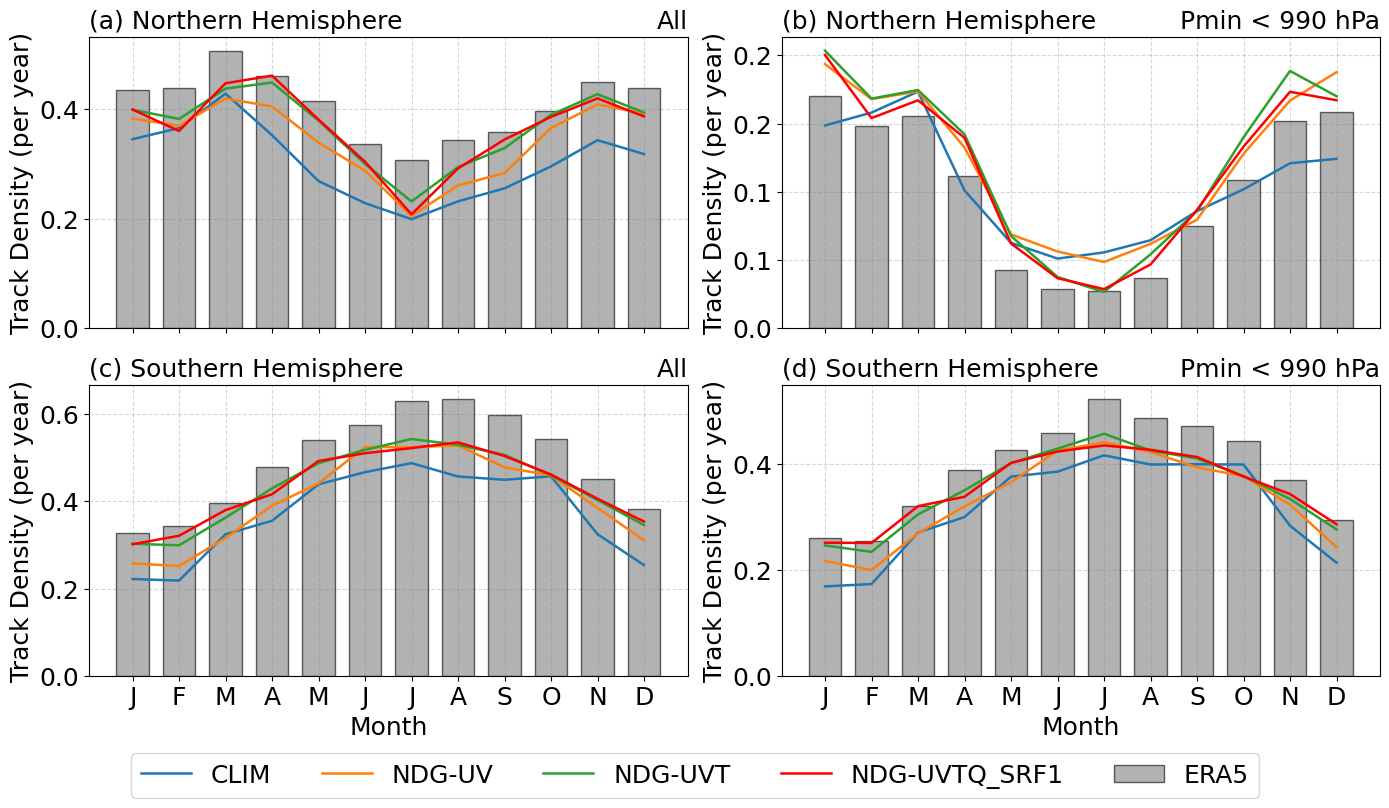

In [20]:
if __name__ == "__main__":
    # === Paths ===
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data/TempestExtremes/ETCS/trk_fnl"
    out_path =  f"{top_path}/post_data/TempestExtremes/ETCS/trk_fnl"
    fig_path = "."
    os.makedirs(fig_path, exist_ok=True)

    # === Time Range & Binning ===
    syear, eyear = 2008, 2017
    bin_size = (4.0, 4.0)
    bin_string = f"bin{int(bin_size[0])}x{int(bin_size[1])}"
    obs_label = "ERA5"
    fig_name = "Figure_10.pdf"
    
    # === Experiments (ERA5 + models) ===
    exp_dict = {
        "ERA5": "ERA5",
        "CLIM": "CLIM",
        "NDGUV": "NDG-UV",
        "NDGUVT": "NDG-UVT",
        "NDGUVTQ_SRF1": "NDG-UVTQ_SRF1"
    }
    
    generate_track_density = False #True
    if generate_track_density:
        all_experiments = list(exp_dict.keys())
        for group in ["Track_P990", "Track_all"]:
            for exp in all_experiments:
                print(f"[INFO] Processing {exp}")
                for year in range(syear, eyear + 1):
                    txt_path = os.path.join(out_path, exp, f"{exp}_set1_ETCS_{group}_{year}.txt")
                    if not os.path.exists(txt_path):
                        print(f"[SKIP] Missing: {txt_path}")
                        continue

                    calc = ETCTrackMonthlyDensityCalculator(
                        filepath=txt_path,
                        bin_size=bin_size,
                        syear=year,
                        eyear=year
                    )
                    calc.parse_tracks()
                    da_year = calc.to_xarray()
                    da_year = da_year.expand_dims(year=[year])  # Add year dimension

                    out_nc = os.path.join(data_path, exp, f"{exp}_monthly_{group}_{year}.nc")
                    da_year.to_netcdf(out_nc)
                    print(f"[SAVED] {exp}: {out_nc}")
            
    # === Initialize ETC Plotter ===
    plotter = ETCTrackDensityPlotter(
        data_dir=data_path,
        exp_dict=exp_dict,
        syear=syear,
        eyear=eyear,
        obs_label=obs_label,
        label_map=exp_dict,
        binsize=bin_string
    )

    # === Filter out OBS from experiment rows
    plotter.experiments = [exp for exp in exp_dict if exp != obs_label]

    hemisphere_bounds = {
        "Northern Hemisphere": (20, 90, -180, 180),
        "Southern Hemisphere": (-90, -20, -180, 180)
    }

    if fig_name is not None:
        save_path = os.path.join(fig_path,fig_name)
    else:
        save_path = os.path.join(fig_path, f"figure_etc_annual_cycle_{syear}_{eyear}.pdf")
        
    plotter.plot_annual_cycle(
        fontz=18,
        hemisphere_dict=hemisphere_bounds,
        save_path=save_path
    )

[INFO] Loaded 10 years for ERA5 (Track_all)
[INFO] Loaded 10 years for CLIM (Track_all)
[INFO] Loaded 10 years for NDGUV (Track_all)
[INFO] Loaded 10 years for NDGUVT (Track_all)
[INFO] Loaded 10 years for NDGUVTQ_SRF1 (Track_all)
[INFO] Loaded 10 years for ERA5 (Track_P990)
[INFO] Loaded 10 years for CLIM (Track_P990)
[INFO] Loaded 10 years for NDGUV (Track_P990)
[INFO] Loaded 10 years for NDGUVT (Track_P990)
[INFO] Loaded 10 years for NDGUVTQ_SRF1 (Track_P990)
[SAVED] ./Figure_C5.pdf


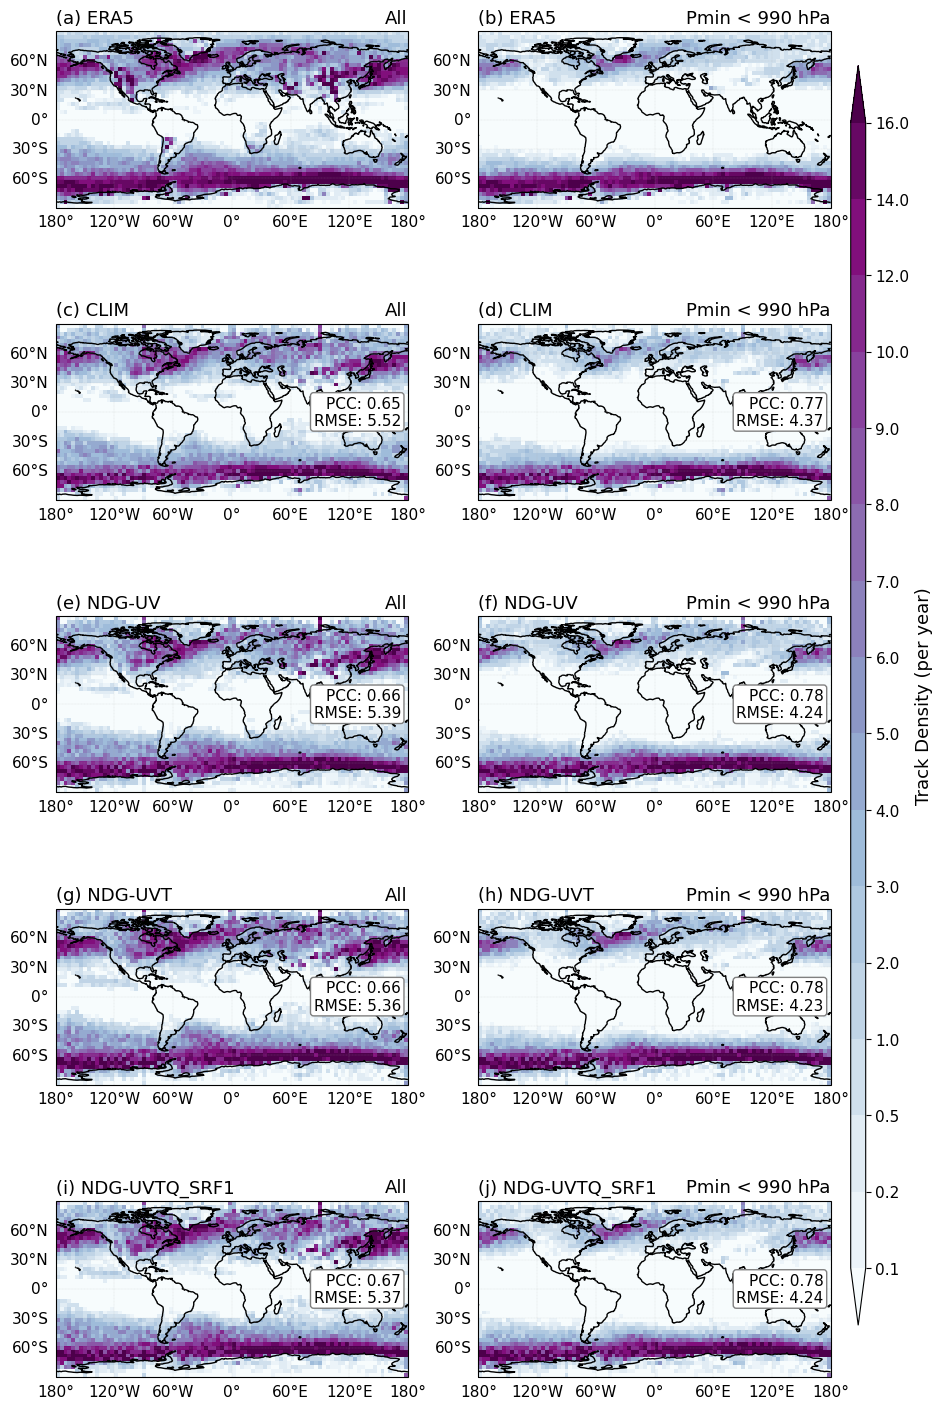

In [19]:
if __name__ == "__main__":
    # === Paths ===
    top_path = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data/TempestExtremes/ETCS/trk_fnl"
    out_path =  f"{top_path}/post_data/TempestExtremes/ETCS/trk_fnl"
    fig_path = "."
    os.makedirs(fig_path, exist_ok=True)

    # === Time Range & Binning ===
    syear, eyear = 2008, 2017
    bin_size = (4.0, 4.0)
    bin_string = f"bin{int(bin_size[0])}x{int(bin_size[1])}"
    obs_label = "ERA5"
    fig_name = "Figure_C5.pdf"
    
    # === Experiments (ERA5 + models) ===
    exp_dict = {
        "ERA5": "ERA5",
        "CLIM": "CLIM",
        "NDGUV": "NDG-UV",
        "NDGUVT": "NDG-UVT",
        "NDGUVTQ_SRF1": "NDG-UVTQ_SRF1"
    }
    
    generate_track_density = False #True
    if generate_track_density:
        all_experiments = list(exp_dict.keys())
        for group in ["Track_P990", "Track_all"]:
            for exp in all_experiments:
                print(f"[INFO] Processing {exp}")
                for year in range(syear, eyear + 1):
                    txt_path = os.path.join(out_path, exp, f"{exp}_set1_ETCS_{group}_{year}.txt")
                    if not os.path.exists(txt_path):
                        print(f"[SKIP] Missing: {txt_path}")
                        continue

                    calc = ETCTrackMonthlyDensityCalculator(
                        filepath=txt_path,
                        bin_size=bin_size,
                        syear=year,
                        eyear=year
                    )
                    calc.parse_tracks()
                    da_year = calc.to_xarray()
                    da_year = da_year.expand_dims(year=[year])  # Add year dimension

                    out_nc = os.path.join(data_path, exp, f"{exp}_monthly_{group}_{year}.nc")
                    da_year.to_netcdf(out_nc)
                    print(f"[SAVED] {exp}: {out_nc}")
            
    # === Initialize ETC Plotter ===
    plotter = ETCTrackDensityPlotter(
        data_dir=data_path,
        exp_dict=exp_dict,
        syear=syear,
        eyear=eyear,
        obs_label=obs_label,
        label_map=exp_dict,
        binsize=bin_string
    )

    # === Filter out OBS from experiment rows
    plotter.experiments = [exp for exp in exp_dict if exp != obs_label]

    hemisphere_bounds = {
        "Northern Hemisphere": (20, 90, -180, 180),
        "Southern Hemisphere": (-90, -20, -180, 180)
    }

    # === Plot Both Metrics Side-by-Side ===
    clevels = [0.1, 0.2, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16]
    cticks = clevels
    
    if fig_name is not None:
        save_path = os.path.join(fig_path,fig_name)
    else:
        save_path = os.path.join(fig_path, f"figure_etc_track_density_climatology_{syear}_{eyear}.pdf")
    
    plotter.plot(
        metrics=["Track_all", "Track_P990"],  # This activates 2-column mode
        cmap="BuPu",
        clevels=clevels,
        cticks=cticks,
        figsize=(10,18),
        fontz=13,
        hspace=0.35,
        wspace=0.2,
        save_path=save_path
    )
    